## Próximas etapas

Agora você pode:

1. **Executar o treinamento dos modelos sklearn** - As funções automáticamente logam tudo no MLflow
2. **Verificar os experimentos**:
   ```python
   listar_experimentos_mlflow()  # Lista todos os experimentos
   comparar_modelos_mlflow()     # Compara performance dos modelos
   ```
3. **Iniciar o MLflow UI** (em um terminal):
   ```bash
   cd c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis
   mlflow ui --backend-store-uri file:///$(pwd)/mlruns
   ```
   Depois acesse `http://localhost:5000`

**Estrutura de dados MLflow:**
- 📁 `mlruns/` → pasta com experimentos
- 📊 Cada experimento contém múltiplos "runs" (treinamentos)
- 📈 Cada run contém: parâmetros, métricas e artefatos (modelos)

In [1]:
# === Visualização de Experimentos MLflow ===

from mlflow.tracking.client import MlflowClient

def listar_experimentos_mlflow():
    """Lista todos os experimentos e runs do MLflow"""
    client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
    
    # Listar todos os experimentos
    experiments = client.search_experiments()
    print(f"Total de experimentos: {len(experiments)}\n")
    
    for exp in experiments:
        print(f"📊 Experimento: {exp.name} (ID: {exp.experiment_id})")
        
        # Listar runs deste experimento
        runs = client.search_runs(experiment_ids=[exp.experiment_id], max_results=10)
        print(f"   Runs: {len(runs)}")
        
        for run in runs[:5]:  # Mostrar apenas os 5 primeiros
            status = "✅" if run.info.status == "FINISHED" else "⏳"
            rmse = run.data.metrics.get("rmse", None)
            rmse_str = f"{rmse:.4f}" if rmse else "N/A"
            print(f"   {status} {run.info.run_name} - RMSE: {rmse_str}")
        
        if len(runs) > 5:
            print(f"   ... e mais {len(runs) - 5} runs")
        print()
        
def _find_mlflow_experiment(client, experiment_name):
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment:
        return experiment

    experiments = client.search_experiments()
    matches = [
        exp for exp in experiments
        if exp.name == experiment_name
        or exp.name.endswith(experiment_name)
        or experiment_name in exp.name
    ]

    if len(matches) == 1:
        print(f"Usando experimento encontrado: {matches[0].name} (ID: {matches[0].experiment_id})")
        return matches[0]

    if len(matches) > 1:
        print(f"Vários experimentos correspondem a '{experiment_name}':")
        for exp in matches:
            print(f" - {exp.name} (ID: {exp.experiment_id})")
        print(f"Usando o primeiro experimento: {matches[0].name}")
        return matches[0]

    return None


def comparar_modelos_mlflow(EXPERIMENTO_NOME):
    """Compara métricas de todos os modelos treinados"""
    client = MlflowClient(tracking_uri=mlflow.get_tracking_uri())
    
    # Buscar runs do experimento atual
    experiment = _find_mlflow_experiment(client, EXPERIMENTO_NOME)
    if not experiment:
        print(f"Experimento '{EXPERIMENTO_NOME}' não encontrado")
        return
    
    runs = client.search_runs(experiment_ids=[experiment.experiment_id])
    
    # Criar DataFrame com resultados
    resultados = []
    for run in runs:
        if run.data.metrics:
            resultados.append({
                "run_name": run.info.run_name,
                "rmse": run.data.metrics.get("rmse"),
                "mae": run.data.metrics.get("mae"),
                "mape": run.data.metrics.get("mape"),
                "mdape": run.data.metrics.get("mdape"),
                "r2": run.data.metrics.get("r2"),
                "feature_transformes" : run.data.tags.get("feature_transform_map"),
                "parametros": run.data.params,
                "features": run.data.tags.get('feature_history_columns'),
                "modelo": run.data.tags.get("modelo"),
                "status": run.info.status,
            })
    
    df_comparacao = pd.DataFrame(resultados).sort_values("mdape", na_position="last")
    if df_comparacao.empty:
        print(f"Nenhum run com métricas encontrado para o experimento '{experiment.name}' (ID: {experiment.experiment_id}).")
    else:
        print("Comparação de modelos treinados:")
        print(df_comparacao.to_string(index=False))
    
    return df_comparacao

c:\Users\jefer\Documents\Ciencia-de-dados\Preco-Imoveis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Como usar MLflow

**Exemplos de uso:**

1. **Treinar modelo sklearn com logging MLflow:**
   ```python
   modelo = RandomForestRegressor(n_estimators=200)
   pipe, metricas = treinar_pipeline_com_mlflow(
       "rf_modelo_v1", modelo, X_train, y_train, X_test, y_test, criar_preprocessador
   )
   ```

2. **Otimizar MLP com Optuna + MLflow:**
   ```python
   study, best_mlp = otimizar_mlp_com_mlflow(
       n_trials=30, 
       X=X_train_keras, 
       y=y_train_log, 
       input_dim=X_train_keras.shape[1]
   )
   ```

3. **Visualizar experimentos no MLflow UI:**
   ```bash
   mlflow ui --backend-store-uri file://<seu-caminho>/mlruns
   ```

**Dados rastreados:**
- ✅ Hiperparâmetros do modelo
- ✅ Métricas (RMSE, MAE, MAPE, R²)
- ✅ Modelo serializado (`.pkl`, `.keras`)
- ✅ Metadados (target, n_features, etc)

In [2]:
def _log_feature_history(X, run_name=None):
    """Registra histórico de features no MLflow para o run atual."""
    try:
        cols = list(X.columns) if hasattr(X, "columns") else []
        mlflow.set_tag("feature_history_run_name", run_name or "")
        mlflow.set_tag("feature_history_num_columns", len(cols))
        if cols:
            mlflow.set_tag("feature_history_columns", ",".join(cols[:50]))
            if len(cols) > 50:
                mlflow.set_tag("feature_history_columns_truncated", "true")

            feature_history_path = Path(tempfile.mkdtemp()) / "feature_history.csv"
            pd.DataFrame({"feature": cols}).to_csv(feature_history_path, index=False)
            mlflow.log_artifact(str(feature_history_path), artifact_path="feature_history")
    except Exception as exc:
        print(f"⚠️ Falha ao logar feature history: {exc}")


def _log_feature_store(
    X,
    run_name,
    feature_group_name,
    description,
    source,
    ):
    """Registra metadados de feature store no MLflow para o run atual."""
    try:
        mlflow.set_tag("feature_store_run_name", run_name or "")
        mlflow.set_tag("feature_store_group_name", feature_group_name)
        mlflow.set_tag("feature_store_description", description)
        mlflow.set_tag("feature_store_source", source)
        mlflow.set_tag("feature_store_num_columns", X.shape[1] if hasattr(X, "shape") else None)

        cols = list(X.columns) if hasattr(X, "columns") else []
        if cols:
            feature_store_path = Path(tempfile.mkdtemp()) / "feature_store.csv"
            pd.DataFrame({"feature": cols}).to_csv(feature_store_path, index=False)
            mlflow.log_artifact(str(feature_store_path), artifact_path="feature_store")
    except Exception as exc:
        print(f"⚠️ Falha ao logar feature store: {exc}")


def treinar_pipeline_com_mlflow(nome, estimador, X_tr, y_tr, X_te, y_te, criar_preprocessador_fn, fit_kwargs=None):
    """Treina um pipeline com logging automático de métricas e parâmetros no MLflow."""
    mlflow.start_run(run_name=nome)
    is_keras_model = hasattr(estimador, "save") and not hasattr(estimador, "get_params")
    mlflow.set_tag("modelo_tipo", "keras" if is_keras_model else "sklearn")
    mlflow.set_tag("target", TARGET)
    mlflow.set_tag("n_features", X_tr.shape[1])
    _log_feature_history(X_tr, run_name=nome)
    _log_feature_store(
        X_tr,
        run_name=nome,
        feature_group_name="joinville_imoveis",
        description="Features do modelo de preço de imóveis em Joinville",
        source="joinville_historico_imoveis",
    )

    if callable(criar_preprocessador_fn):
        preprocessor = criar_preprocessador_fn()
    else:
        preprocessor = criar_preprocessador_fn

    if preprocessor is None:
        raise ValueError("`criar_preprocessador_fn` deve retornar um preprocessor ou receber um objeto transformador.")

    try:
        if is_keras_model:
            X_tr_pre = preprocessor.fit_transform(X_tr)
            X_te_pre = preprocessor.transform(X_te)
            fit_kwargs = fit_kwargs or {}
            estimador.fit(X_tr_pre, y_tr, validation_data=(X_te_pre, y_te), verbose=0, **fit_kwargs)
            pred = estimador.predict(X_te_pre).ravel()
            mlflow.keras.log_model(estimador, artifact_path=nome)

            preprocessor_path = Path(tempfile.mkdtemp()) / "preprocessor.joblib"
            joblib.dump(preprocessor, preprocessor_path)
            mlflow.log_artifact(str(preprocessor_path), artifact_path=nome)
            trained_model = estimador
        else:
            pipe = Pipeline([
                ("preprocessador", preprocessor),
                ("modelo", estimador),
            ])
            pipe.fit(X_tr, y_tr)
            pred = pipe.predict(X_te)
            mlflow.sklearn.log_model(pipe, name=nome)
            trained_model = pipe

            if hasattr(estimador, "get_params"):
                params = estimador.get_params()
                for k, v in list(params.items())[:20]:
                    v_str = str(v)[:100] if v is not None else "None"
                    mlflow.log_param(f"modelo__{k}", v_str)

        rmse = mean_squared_error(y_te, pred) ** 0.5
        mae = mean_absolute_error(y_te, pred)
        mape = np.mean(np.abs((y_te - pred) / y_te)) * 100
        r2 = r2_score(y_te, pred)

        mlflow.log_metric("rmse", float(rmse))
        mlflow.log_metric("mae", float(mae))
        mlflow.log_metric("mape", float(mape))
        mlflow.log_metric("r2", float(r2))
        mlflow.log_metric("n_train", len(X_tr))
        mlflow.log_metric("n_test", len(X_te))

        print(f"{nome}: RMSE=R$ {rmse:,.0f} | MAE=R$ {mae:,.0f} | MAPE={mape:.1f}% | R²={r2:.3f}")
        return trained_model, {"rmse": rmse, "mae": mae, "mape": mape, "r2": r2}
    finally:
        mlflow.end_run()
        


def _build_keras_from_trial(trial, input_dim):
    """Reconstrói um modelo Keras a partir dos parâmetros de um trial Optuna."""
    def _trial_param(name):
        params = getattr(trial, "_params", None) or getattr(trial, "params", None) or {}
        return params.get(name, None)

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    num_camadas = _trial_param("num_camadas")
    if num_camadas is None:
        num_camadas = trial.suggest_int("num_camadas", 1, 4)

    for i in range(num_camadas):
        unidades = _trial_param(f"unidades_{i}")
        if unidades is None:
            unidades = trial.suggest_int(f"unidades_{i}", 64, 512, step=64)

        dropout = _trial_param(f"dropout_{i}")
        if dropout is None:
            dropout = trial.suggest_float(f"dropout_{i}", 0.0, 0.4, step=0.1)

        model.add(layers.Dense(int(unidades), activation="relu"))
        if dropout and float(dropout) > 0:
            model.add(layers.Dropout(float(dropout)))

    model.add(layers.Dense(1))
    lr = _trial_param("learning_rate")
    if lr is None:
        lr = trial.suggest_categorical("learning_rate", [1e-2, 1e-3, 1e-4, 1e-5])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=["mae"]
    )
    return model


In [3]:
import numpy as np
import optuna
import mlflow
import keras
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

def otimizar_mlp_com_mlflow(n_trials,
                             X_train_keras, 
                             y_train_keras,
                            x_val_keras,
                            y_val_keras,
                            input_dim, 
                            epochs=100, 
                            nome="mlp_keras"):
    """Otimização de MLP com Optuna e logging de múltiplas métricas no MLflow"""
    mlflow.end_run()
    mlflow.start_run(run_name=nome)
    try:
        mlflow.set_tag("modelo", "keras")
        mlflow.set_tag("target", TARGET)
        _log_feature_history(X_train, run_name=nome)
        _log_feature_store(
            X_train,
            run_name=nome,
            feature_group_name="joinville_imoveis",
            description="Features do modelo de MLP otimizado",
            source="joinville_historico_imoveis",
        )
        mlflow.log_param("n_trials", n_trials)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("input_dim", input_dim)

        def objective_mlp(trial):
            # 1. Separar manualmente o split de validação para calcular as métricas extras no final do trial

            model = _build_keras_from_trial(trial, input_dim)
            batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])

            early_stop = keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=10, restore_best_weights=True
            )
            
            # Treina usando a nossa divisão manual idêntica ao split do Keras
            history = model.fit(
                X_train_keras, y_train_keras, validation_data=(x_val_keras, y_val_keras), epochs=epochs, batch_size=batch_size,
                callbacks=[early_stop], verbose=0
            )

            # 2. Resgatar as predições de validação para gerar as métricas
            preds_log = model.predict(x_val_keras, verbose=0).ravel()
            
            y_va_real = np.expm1(y_val_keras)
            
            preds_real = np.expm1(preds_log)

            rmse = np.sqrt(np.mean((y_va_real - preds_real) ** 2))
            
            mae = mean_absolute_error(y_va_real, preds_real)
            
            mape = mean_absolute_percentage_error(y_va_real, preds_real)
            
            r2 = r2_score(y_va_real, preds_real)

            # 4. Enviar os dados do Trial para o MLflow
            #with mlflow.start_run(nested=True):
            with mlflow.start_run(nested=True, run_name=f"{nome}_trial_{trial.number}"):
                mlflow.set_tag("modelo", "keras")
                for param_name, param_value in trial.params.items():
                    param_str = str(param_value)[:100]
                    mlflow.log_param(param_name, param_str)
                
                # Logging do pacote completo de métricas
                mlflow.log_metric("rmse", float(rmse))
                mlflow.log_metric("mae", float(mae))
                mlflow.log_metric("mape", float(mape))
                mlflow.log_metric("r2", float(r2))
                mlflow.log_metric("best_epoch", len(history.history.get("loss", [])))
                _log_feature_history(X_train, run_name=nome)
                _log_feature_store(
                    X_train,
                    run_name=nome,
                    feature_group_name="joinville_imoveis",
                    description="Features do modelo de MLP otimizado",
                    source="joinville_historico_imoveis",
                )

            return rmse

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=42)
        )
        study.optimize(objective_mlp, n_trials=n_trials, show_progress_bar=True)

        for param_name, param_value in study.best_params.items():
            param_str = str(param_value)[:100]
            mlflow.log_param(f"best_{param_name}", param_str)

        mlflow.log_metric("best_rmse", study.best_value)
        
        mlflow.log_metric("total_trials", n_trials)

        best_model = _build_keras_from_trial(optuna.trial.FixedTrial(study.best_params), input_dim)
        early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
        
        best_model.fit(
            X_train_keras, y_train_keras, validation_data=(x_val_keras, y_val_keras), epochs=200,
            batch_size=study.best_params.get("batch_size", 256),
            callbacks=[early_stop], verbose=0
        )

        mlflow.keras.log_model(best_model, name="keras_model_best")

        print(f"MLP otimizado: melhor RMSE = {study.best_value:,.4f}")

        return study, best_model
    finally:
        mlflow.end_run()

## MLflow - Tracking de Experimentos

Rastreamento automático de modelos, métricas e hiperparâmetros com **MLflow**. Todos os modelos treinados serão logados em `../mlruns/`.

# Modelo de precificação — Joinville

Predição de `valor_imovel` com características do imóvel, contexto de preço por bairro/tipo e índice de localização (`score`).

**Evita vazamento de dados:** não usa `preco_por_m2`, `desvio_mediana` nem `faixa` (derivados do preço de venda).

In [4]:
import json
import os
import tempfile
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import optuna
import shap
from sklearn.model_selection import KFold, cross_val_score
import mlflow
import mlflow.sklearn
import mlflow.keras
from mlflow.tracking import MlflowClient

import keras
from keras import layers
import keras_tuner as kt
import os
from dotenv import load_dotenv
load_dotenv()


# ===== Configuração Databricks =====

def normalize_databricks_host(host):
    if not host:
        return host
    from urllib.parse import urlparse

    parsed = urlparse(host.strip())
    if parsed.scheme and parsed.netloc:
        return f"{parsed.scheme}://{parsed.netloc}"
    return host.strip().rstrip("/")


raw_host = os.getenv("DATABRICKS_HOST", "")
DATABRICKS_HOST = normalize_databricks_host(raw_host)
DATABRICKS_TOKEN = os.getenv("DATABRICKS_TOKEN", os.getenv("API_KEY_DATABRICKS", ""))
DATABRICKS_CONFIG_PROFILE = os.getenv("DATABRICKS_CONFIG_PROFILE", "")
masked_token = f"{DATABRICKS_TOKEN[:4]}..." if DATABRICKS_TOKEN else ""

print("Configurações de autenticação do Databricks:")
print(f"  Original DATABRICKS_HOST: {raw_host}")
print(f"  Normalized DATABRICKS_HOST: {DATABRICKS_HOST}")
print(f"  DATABRICKS_TOKEN: {masked_token}")
print(f"  DATABRICKS_CONFIG_PROFILE: {DATABRICKS_CONFIG_PROFILE}")
 
from  mlflow_manager import MLflowManager

# Ou explicito:
mlf = MLflowManager(
    nome_experimento="joinville_imoveis",
    databricks_workspace_path="/Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville",
)



Configurações de autenticação do Databricks:
  Original DATABRICKS_HOST: https://dbc-ed602b14-1f14.cloud.databricks.com
  Normalized DATABRICKS_HOST: https://dbc-ed602b14-1f14.cloud.databricks.com
  DATABRICKS_TOKEN: dapi...
  DATABRICKS_CONFIG_PROFILE: 


In [5]:
mlf.conectar()

mlf.listar_experimentos()
df_compa = mlf.comparar_modelos("imoveis-joinville-valor")

[MLflow] Databricks (token): https://dbc-ed602b14-1f14.cloud.databricks.com
[MLflow] Experimento: /Workspace/Users/sehnemjeferson@gmail.com/imoveis-joinville
Total de experimentos: 21

Experimento: /Users/sehnemjeferson@gmail.com/imoveis-rio_janeiro-recreio-bandeirantes-valor (ID: 3938833238111023)
   Runs: 10
   ... CatBoost|std_median_ohe|log_std_median_ohe|log|tgt_none_2026_06 - RMSE: N/A
   OK RandomForest|std_median_ohe|log_std_median_ohe|log|tgt_log_2026_06 - RMSE: 1030540.5268
   OK DecisionTree|std_median_ohe|log_std_median_ohe|log|tgt_log_2026_06 - RMSE: 1024846.4630
   OK GradientBoosting|std_median_ohe|log_std_median_ohe|log|tgt_none_2026_06 - RMSE: 1024494.9890
   OK RandomForest|std_median_ohe|log_std_median_ohe|log|tgt_none_2026_06 - RMSE: 971986.5382
   ... e mais 5 runs

Experimento: /Users/sehnemjeferson@gmail.com/imoveis-joinville-valor (ID: 3220922994350712)
   Runs: 10
   OK best_geral_GradientBoosting_todas_feats - RMSE: N/A
   OK best_DecisionTree|robust_median_oh

## Carregar dados

## Adcionando indices de localizacao individual (Escolas, comercio, transporte, etc)
```python

In [139]:
cidade = 'joinville'

estado = 'sc'

BASE_DIR = Path.cwd().parent
PASTA_DADOS = BASE_DIR / 'dados' / cidade
df = pd.read_parquet(PASTA_DADOS / f'{cidade}_imoveis_limpo_2026-06.parquet')

In [140]:
df.shape

(24336, 62)

In [141]:
df["residuo"] = df["valor_predito"] - df["valor_imovel"]
df["residuo_pct"] = df["residuo"] / df["valor_imovel"] * 100

q1, q3 = df["residuo_pct"].quantile([0.25, 0.75])
iqr = q3 - q1
df = df[(df["residuo_pct"] >= q1 - 1.5*iqr) & (df["residuo_pct"] <= q3 + 1.5*iqr)]

In [135]:
df = df[df['valor_imovel'] < 15000000]

In [142]:
df.shape

(20076, 64)

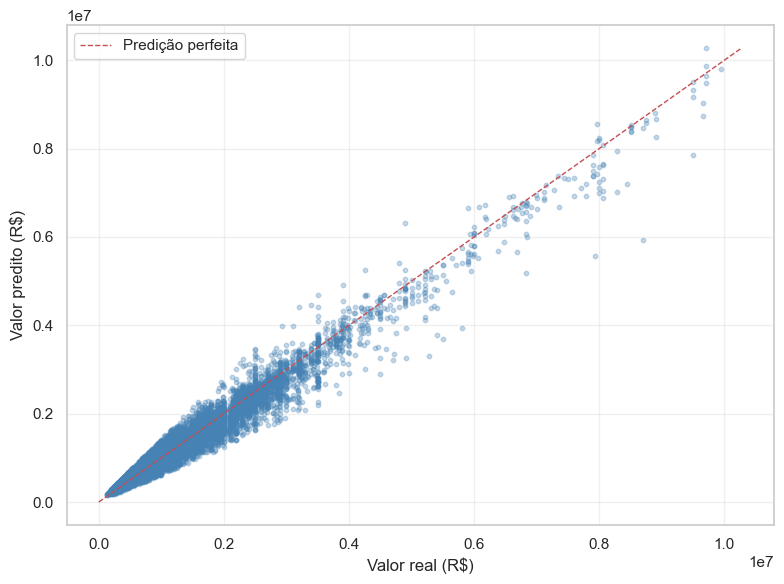

In [123]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df["valor_imovel"], df["valor_predito"],
           alpha=0.3, s=10, c="steelblue")

# Linha de referencia y=x (predicao perfeita)
lim = max(df["valor_imovel"].max(), df["valor_predito"].max())
ax.plot([0, lim], [0, lim], "r--", linewidth=1, label="Predição perfeita")

ax.set_xlabel("Valor real (R$)")
ax.set_ylabel("Valor predito (R$)")
#ax.set_title(f"{CIDADE} — Valor real vs predito")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig("scatter_pred_vs_real.png", dpi=150)
plt.show()

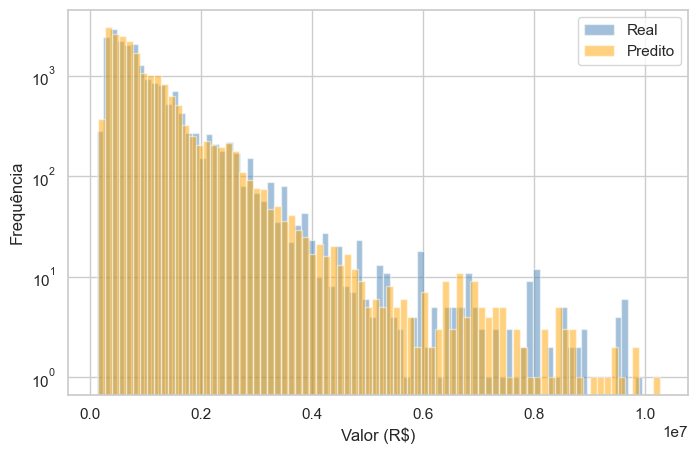

In [124]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["valor_imovel"], bins=80, alpha=0.5, label="Real", color="steelblue")
ax.hist(df["valor_predito"], bins=80, alpha=0.5, label="Predito", color="orange")
ax.set_xlabel("Valor (R$)"); ax.set_ylabel("Frequência"); ax.legend()
ax.set_yscale("log")  # comprime cauda longa

Gráfico gerado com sucesso!


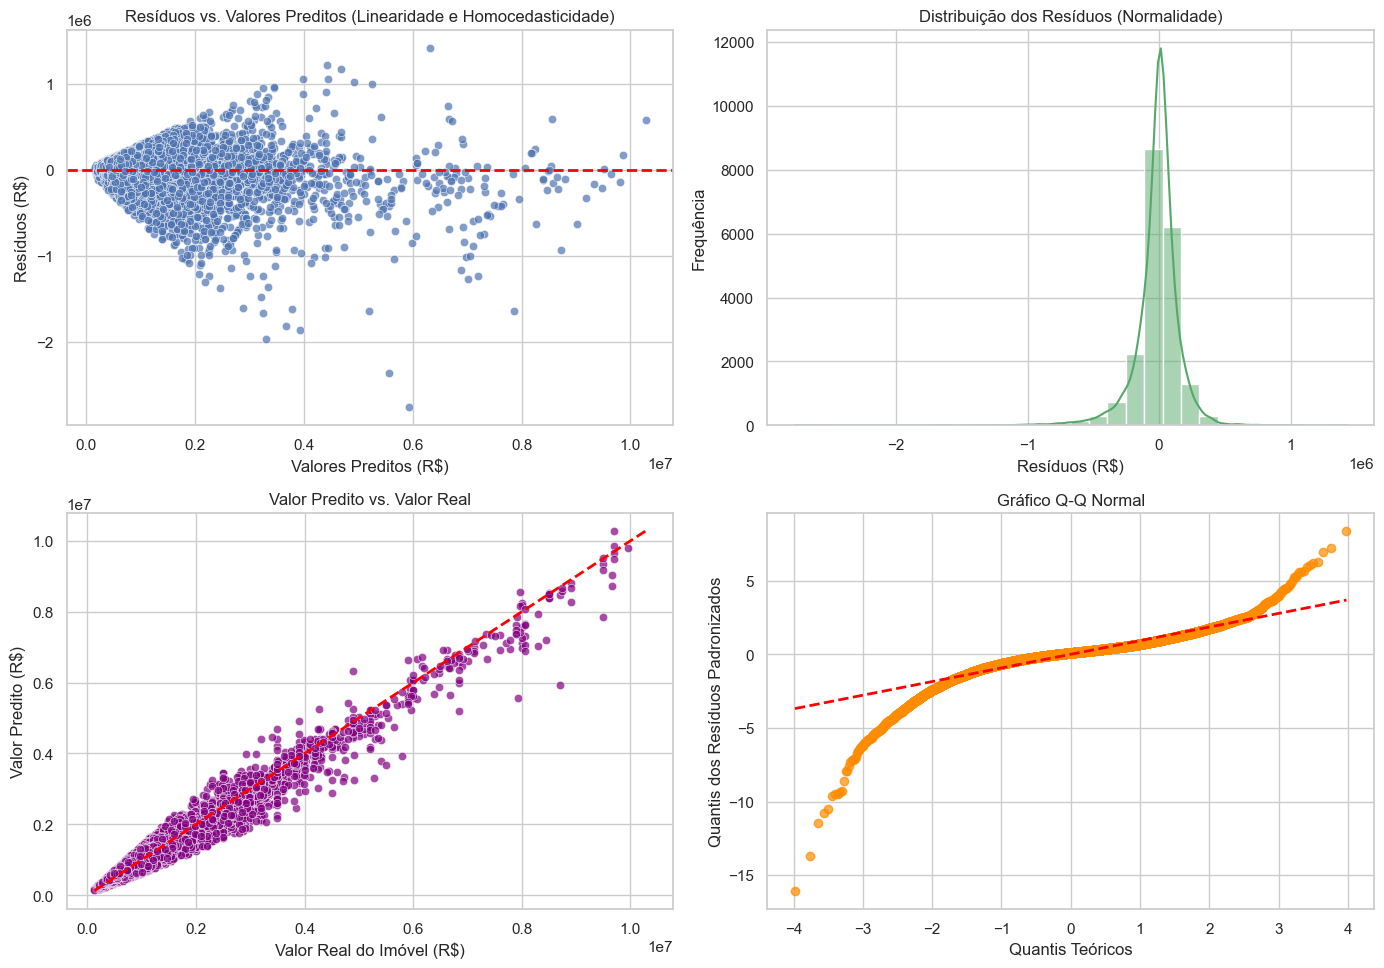

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Configurando o estilo dos gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Resíduos vs Valores Preditos
sns.scatterplot(x=df['valor_predito'], y=df['residuo'], ax=axes[0, 0], alpha=0.7, color='b')
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_title('Resíduos vs. Valores Preditos (Linearidade e Homocedasticidade)')
axes[0, 0].set_xlabel('Valores Preditos (R$)')
axes[0, 0].set_ylabel('Resíduos (R$)')

# 2. Histograma dos Resíduos
sns.histplot(df['residuo'], kde=True, ax=axes[0, 1], color='g', bins=30)
axes[0, 1].set_title('Distribuição dos Resíduos (Normalidade)')
axes[0, 1].set_xlabel('Resíduos (R$)')
axes[0, 1].set_ylabel('Frequência')

# 3. Previsão vs Valor Real (Linha de Identidade)
sns.scatterplot(x=df['valor_imovel'], y=df['valor_predito'], ax=axes[1, 0], alpha=0.7, color='purple')
max_val = max(df['valor_imovel'].max(), df['valor_predito'].max())
min_val = min(df['valor_imovel'].min(), df['valor_predito'].min())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
axes[1, 0].set_title('Valor Predito vs. Valor Real')
axes[1, 0].set_xlabel('Valor Real do Imóvel (R$)')
axes[1, 0].set_ylabel('Valor Predito (R$)')

# 4. Q-Q Plot aproximado com Seaborn/Matplotlib
import scipy.stats as stats
residuos_padronizados = (df['residuo'] - df['residuo'].mean()) / df['residuo'].std()
(osm, osr), (slope, intercept, r) = stats.probplot(residuos_padronizados, dist="norm")
axes[1, 1].scatter(osm, osr, alpha=0.7, color='darkorange')
axes[1, 1].plot(osm, slope*osm + intercept, color="red", linestyle="--", linewidth=2)
axes[1, 1].set_title('Gráfico Q-Q Normal')
axes[1, 1].set_xlabel('Quantis Teóricos')
axes[1, 1].set_ylabel('Quantis dos Resíduos Padronizados')

plt.tight_layout()
plt.savefig('analise_residuos_imoveis.png', dpi=150)
print("Gráfico gerado com sucesso!")